# Step 1: Install Dependencies

In [2]:
pip install stable-baselines3 gym pandas yfinance scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.


# Step 2: Load and Visualize the Data

We will load the stock market data (columns: Date, Open, High, Low, Close, Volume) and visualize it.

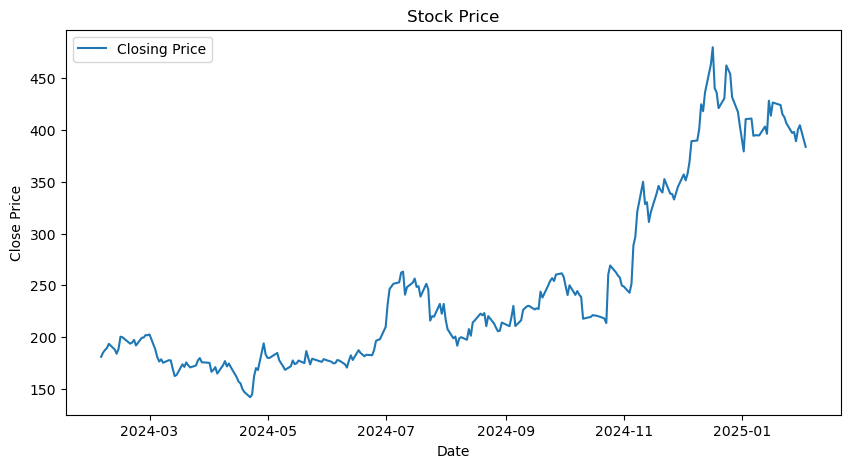

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('tesla.csv', parse_dates=['Date'], index_col='Date')

# Visualize the closing price
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Closing Price')
plt.title('Stock Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Step 3: Feature Engineering

We will create useful technical indicators for the model:

* SMA (Simple Moving Average): Average price over a period.
* EMA (Exponential Moving Average): Emphasizes recent prices.
* Volatility: Rolling standard deviation of returns.
* RSI (Relative Strength Index): Momentum oscillator.
* MACD: Difference between short and long-term EMAs.

In [6]:
# Moving averages
data['SMA_10'] = data['Close'].rolling(window=10).mean()
data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()

# Daily returns and volatility
data['Daily_Return'] = data['Close'].pct_change()
data['Volatility'] = data['Daily_Return'].rolling(window=10).std()

# Relative Strength Index (RSI)
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

data['RSI'] = compute_rsi(data['Close'])

# Drop NaN values
data = data.dropna()


In [7]:
data

,Open,High,Low,Close,Volume,SMA_10,EMA_10,Daily_Return,Volatility,RSI
Date,,,,,,,,,,
2025-01-14,414.34,422.64,394.54,396.36,"84,565,023",411.828,410.246255,-0.074401,0.032361,54.708853
2025-01-13,383.21,403.79,380.07,403.31,"67,580,484",412.350,408.985118,0.017535,0.032010,56.931987
2025-01-10,391.40,399.28,377.29,394.74,"62,287,328",412.109,406.395096,-0.021249,0.032828,46.185392
2025-01-08,392.95,402.50,387.40,394.94,"73,038,805",410.945,404.312351,0.000507,0.031757,47.866049
2025-01-07,405.83,414.33,390.00,394.36,"75,699,531",409.143,402.502833,-0.001469,0.031223,52.296542
...,...,...,...,...,...,...,...,...,...,...
2024-02-09,190.18,194.12,189.48,193.57,"84,476,352",193.274,192.096103,0.028916,0.031169,41.402844
2024-02-08,189.00,191.62,185.58,189.56,"83,034,039",193.033,191.634993,-0.020716,0.029515,39.000000
2024-02-07,188.18,189.79,182.68,187.58,"111,535,203",192.050,190.897722,-0.010445,0.027746,37.495676


# Step 4: Normalize the Data

We normalize the data to ensure all features are on the same scale, which helps the A2C model converge better.

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Clean columns by removing commas and converting to numeric
data['Open'] = data['Open'].replace(',', '', regex=True).astype(float)
data['High'] = data['High'].replace(',', '', regex=True).astype(float)
data['Low'] = data['Low'].replace(',', '', regex=True).astype(float)
data['Close'] = data['Close'].replace(',', '', regex=True).astype(float)
data['Volume'] = data['Volume'].replace(',', '', regex=True).astype(float)

# Normalize the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(data[['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_10', 'EMA_10', 'Volatility', 'RSI']])

# Store the scaled features in a new DataFrame
scaled_data = pd.DataFrame(scaled_features, columns=['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_10', 'EMA_10', 'Volatility', 'RSI'])


In [10]:
scaled_data

,Open,High,Low,Close,Volume,SMA_10,EMA_10,Volatility,RSI
0,0.816425,0.808486,0.802422,0.752820,0.229303,0.883713,0.884285,0.343955,0.638188
1,0.723594,0.753705,0.757020,0.773393,0.147134,0.885515,0.879859,0.338088,0.666353
2,0.748017,0.740599,0.748298,0.748024,0.121526,0.884683,0.870770,0.351758,0.530207
3,0.752639,0.749956,0.780019,0.748616,0.173541,0.880664,0.863460,0.333861,0.551499
4,0.791048,0.784336,0.788177,0.746899,0.186413,0.874444,0.857110,0.324939,0.607628
...,...,...,...,...,...,...,...,...,...
232,0.147969,0.144377,0.159016,0.152512,0.228874,0.129243,0.118683,0.324039,0.469619
233,0.144450,0.137111,0.146779,0.140641,0.221896,0.128411,0.117065,0.296409,0.439178
234,0.142005,0.131793,0.137680,0.134780,0.359781,0.125018,0.114477,0.266860,0.420120
235,0.109292,0.122203,0.120203,0.127439,0.413679,0.121680,0.110778,0.266773,0.418727


# Step 5: Create the Trading Environment

We create a custom OpenAI Gym environment where:

* State: Technical indicators.
* Actions: Buy, Sell, Hold.
* Reward: Profit from the trade.

In [12]:
import gymnasium as gym
import numpy as np

class TradingEnv(gym.Env):
    def __init__(self, data, initial_balance=10000):
        super(TradingEnv, self).__init__()
        self.data = data
        self.initial_balance = initial_balance
        self.current_step = 0
        self.balance = initial_balance
        self.position = 0  # No position initially
        self.previous_price = 0

        # Action space: 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = gym.spaces.Discrete(3)

        # Observation space: Adjust to ensure compatibility with Gymnasium
        self.observation_space = gym.spaces.Box(
            low=0, high=1, shape=(self.data.shape[1],), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        self.current_step = 0
        self.balance = self.initial_balance
        self.position = 0
        self.previous_price = 0
        return self.data.iloc[self.current_step].values, {}

    def step(self, action):
        current_price = self.data['Close'].iloc[self.current_step]
        reward = 0

        # Perform the action
        if action == 1:  # Buy
            if self.position == 0:  # Can only buy if no current position
                self.position = 1
                self.previous_price = current_price

        elif action == 2:  # Sell
            if self.position == 1:  # Can only sell if holding a position
                reward = current_price - self.previous_price  # Profit/loss from the trade
                self.position = 0

        # Move to the next step
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1

        # Calculate reward for holding the position (or doing nothing)
        reward += (self.position * (current_price - self.previous_price))

        # Observation for the next step
        obs = self.data.iloc[self.current_step].values
        return obs, reward, done, {}, {}

    def render(self):
        print(f'Step: {self.current_step}, Balance: {self.balance}, Position: {self.position}')


# Step 6: Train the A2C Model

We will use Stable-Baselines3 to train the A2C agent using this environment.

In [14]:
pip install shimmy>=2.0

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install gym==0.26.2 gymnasium==0.29.0 stable-baselines3==1.8.0

INFO: pip is looking at multiple versions of stable-baselines3 to determine which version is compatible with other requirements. This could take a while.

The conflict is caused by:
    The user requested gym==0.26.2
    stable-baselines3 1.8.0 depends on gym==0.21

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict

Note: you may need to restart the kernel to use updated packages.


ERROR: Cannot install gym==0.26.2 and stable-baselines3==1.8.0 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [16]:
import gymnasium as gym


In [17]:
pip install gymnasium stable-baselines3


Note: you may need to restart the kernel to use updated packages.


In [18]:
import gymnasium as gym


In [ ]:
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import DummyVecEnv

# Create the environment using Gymnasium-compatible setup
env = DummyVecEnv([lambda: TradingEnv(scaled_data)])

# Train the A2C agent
a2c_model = A2C("MlpPolicy", env, verbose=1)
a2c_model.learn(total_timesteps=10000)


Using cuda device


C:\Users\goel\anaconda3\ANACONDA\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


------------------------------------
| time/                 |          |
|    fps                | 15       |
|    iterations         | 100      |
|    time_elapsed       | 31       |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -1.08    |
|    explained_variance | -0.903   |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.23    |
|    value_loss         | 0.0526   |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 27       |
|    iterations         | 200      |
|    time_elapsed       | 36       |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -0.988   |
|    explained_variance | -21      |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | 0.0603   |
|    value_loss         | 0.00677  |
-

# Step 7: Test the A2C Agent

We will reset the environment and let the agent make decisions.

In [ ]:
obs = env.reset()
total_rewards = 0

for step in range(1000):
    action, _states = a2c_model.predict(obs)
    obs, reward, done, _ = env.step(action)
    total_rewards += reward
    env.render()
    
    if done:
        print(f"Final Total Reward: {total_rewards}")
        break


# Step 8: Evaluate the Performance

We can visualize and evaluate the trading performance using:

* Cumulative Returns
* Profit per Trade
* Win Rate

In [ ]:
# Example to plot cumulative rewards over time (modify this based on your reward logic)
plt.figure(figsize=(10, 5))
plt.plot([reward for _ in range(1000)], label='Cumulative Reward')
plt.xlabel('Time Step')
plt.ylabel('Cumulative Reward')
plt.title('A2C Trading Performance')
plt.legend()
plt.show()
